## Section 0 - Setup

In [59]:
import json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

ROOT_DIR  = Path.cwd().parent
RAW_DIR   = ROOT_DIR / "data" / "raw"
DATA_DIR  = ROOT_DIR / "data"
MODEL_DIR = ROOT_DIR / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## Section 1 - Load & Split

In [60]:
df = pd.read_csv(RAW_DIR / "train.csv")
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

# Columns a first-time buyer cannot describe -- removed before split.
# Reviewed by domain experts: removing unuseful features for user experience or irrelevant to propery price
EXCLUDE_INTERNAL = {
    "MSSubClass",    # not buyer-known
    "MoSold",        # month sold -- irrelevant to describing the property
    "YrSold",        # year sold -- irrelevant to describing the property
    "OverallCond",   # condition rating -- overlaps with quality, too subjective
    "BsmtFinSF2",    # second type of finished basement sqft -- overly detailed
    "LowQualFinSF",  # low-quality finished area above grade -- too technical
    "BsmtHalfBath",  # basement half baths -- overly detailed
    "KitchenAbvGr",  # number of kitchens -- almost always 1, no signal
    "EnclosedPorch", # enclosed porch sqft -- buyer unlikely to know sqft
    "3SsnPorch",     # three-season porch sqft -- overly detailed
    "ScreenPorch",   # screen porch sqft -- overly detailed
    "PoolArea",      # pool sqft -- too tech - buyer would say yes/no, not sqft
    "MiscVal",       # value of miscellaneous feature -- too technical
    "TotRmsAbvGrd",  # total rooms -- redundant with GrLivArea
}

X = df.drop(columns=['SalePrice'] + list(EXCLUDE_INTERNAL))
y = np.log1p(df['SalePrice'])  # log-transform: compresses right skew, handles outliers

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15/0.85, random_state=42)

print(f"Removed {len(EXCLUDE_INTERNAL)} non-user-friendly columns")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Removed 14 non-user-friendly columns
Train: (1022, 66) | Val: (219, 66) | Test: (219, 66)


## Section 2 - EDA: Column types and Outliers


In [61]:
# Column overview -- X_train only
print(f"Numeric columns : {X_train.select_dtypes(include='number').shape[1]}")
print(f"Categorical cols: {X_train.select_dtypes(include='object').shape[1]}")
print(f"Total null cells: {X_train.isnull().sum().sum()}")

Numeric columns : 23
Categorical cols: 43
Total null cells: 5482


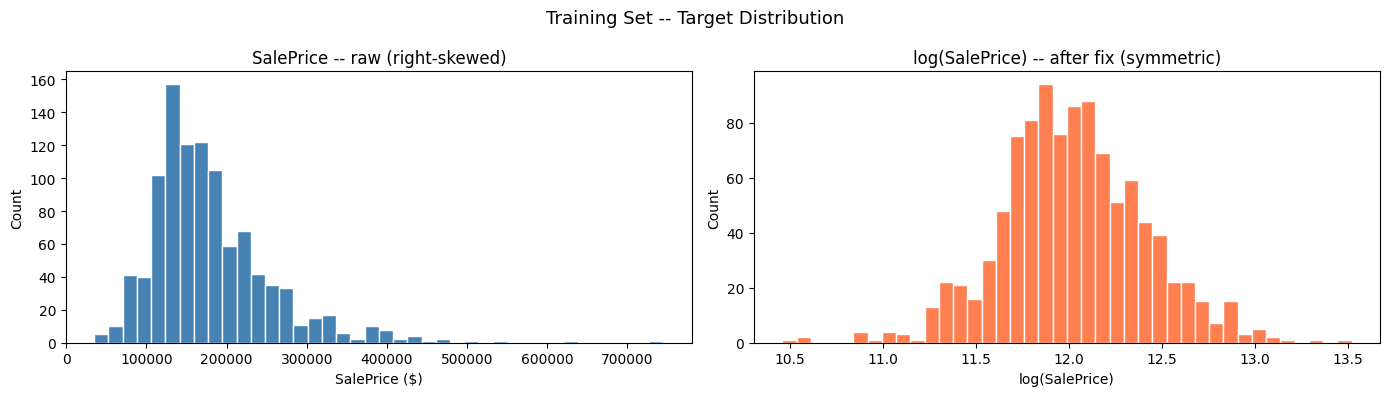

count      1022.0
mean     179207.0
std       74853.0
min       34900.0
25%      129900.0
50%      164945.0
75%      213875.0
max      745000.0
Name: SalePrice, dtype: float64 

initial skew: 1.7203687652547728
compressed skew: 0.02973732699816881


In [62]:
# Target distribution -- y_train only
# Left: raw dollars (shows the skew problem)
# Right: log scale (shows the fix)
y_train_dollars = np.expm1(y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train_dollars, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice -- raw (right-skewed)')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Count')

axes[1].hist(y_train, bins=40, color='coral', edgecolor='white')
axes[1].set_title('log(SalePrice) -- after fix (symmetric)')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Count')

plt.suptitle('Training Set -- Target Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print(y_train_dollars.describe().round(0), "\n")
print(f"initial skew: {y_train_dollars.skew()}")
print(f"compressed skew: {y_train.skew()}")

## Section 3 - Analysis Preprocessor

In [63]:
print(f"Numeric columns : {X_train.select_dtypes(include='number').columns}")
print(f"Categorical cols: {X_train.select_dtypes(include='object').columns}")

Numeric columns : Index(['Id', 'LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF',
       '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageCars',
       'GarageArea', 'WoodDeckSF', 'OpenPorchSF'],
      dtype='str')
Categorical cols: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFe

In [64]:
# Ordinal feature ordering (low -> high) -- used for analysis encoding and pipeline
ORDINAL_FEATURES = {
    "ExterQual":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual":    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "HeatingQC":   ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageQual":  ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond":  ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
}

# Clean copy of X_train for correlation analysis only -- does NOT feed the model
X_analysis = X_train.copy()

# Impute numeric nulls with median (same strategy the pipeline will use)
for col in X_analysis.select_dtypes(include='number').columns:
    X_analysis[col] = X_analysis[col].fillna(X_analysis[col].median())

# Encode ordinals to integers so they participate in correlation
for feat, levels in ORDINAL_FEATURES.items():
    if feat in X_analysis.columns:
        mapping = {v: i for i, v in enumerate(levels)}
        X_analysis[feat] = X_analysis[feat].map(mapping).fillna(0)

# Correlations across all numeric + encoded ordinal columns (X_train only)
correlations = X_analysis.select_dtypes(include='number').corrwith(y_train_dollars).abs().sort_values(ascending=False)

print(f"Top 20 features by |corr| with SalePrice:")
print(correlations.head(20).round(3))

Top 20 features by |corr| with SalePrice:
OverallQual     0.785
GrLivArea       0.689
ExterQual       0.668
KitchenQual     0.643
GarageCars      0.643
GarageArea      0.623
BsmtQual        0.587
TotalBsmtSF     0.579
1stFlrSF        0.572
FullBath        0.552
YearBuilt       0.534
YearRemodAdd    0.509
MasVnrArea      0.485
GarageYrBlt     0.458
Fireplaces      0.456
HeatingQC       0.437
BsmtFinSF1      0.364
WoodDeckSF      0.350
2ndFlrSF        0.329
LotFrontage     0.299
dtype: float64


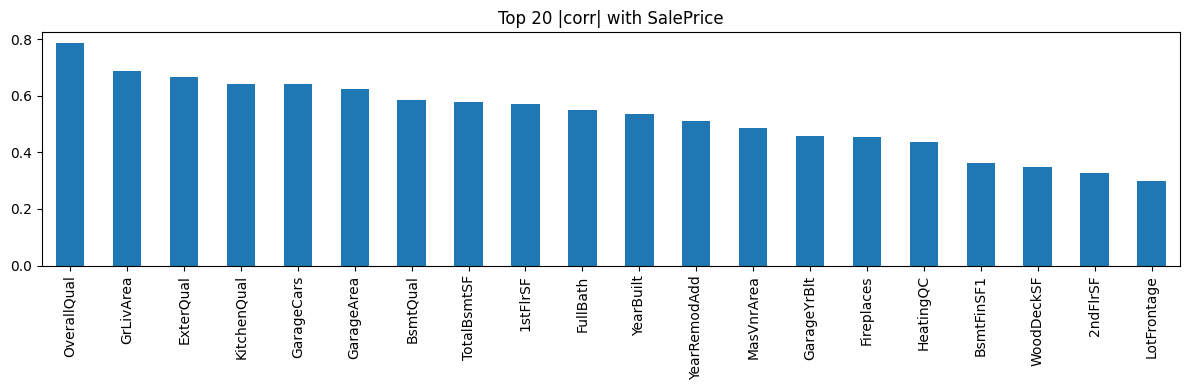

In [65]:
correlations.head(20).plot(kind='bar', figsize=(12, 4), title='Top 20 |corr| with SalePrice')
plt.tight_layout()
plt.show()

## Section 4 - Feature Selection

In [66]:
# Shortlist: features with |corr| >= 0.5
CORR_THRESHOLD = 0.5
shortlist = correlations[correlations >= CORR_THRESHOLD]
print(f"Shortlist ({len(shortlist)}):")
print(shortlist.head(20).round(3))

Shortlist (12):
OverallQual     0.785
GrLivArea       0.689
ExterQual       0.668
KitchenQual     0.643
GarageCars      0.643
GarageArea      0.623
BsmtQual        0.587
TotalBsmtSF     0.579
1stFlrSF        0.572
FullBath        0.552
YearBuilt       0.534
YearRemodAdd    0.509
dtype: float64


In [67]:
# --- LOCKED FEATURE LIST ---
# Review shortlist above, then lock final features here.
# Target: 8-12 buyer-describable features.
NUMERIC_FEATURES       = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF",
                           "1stFlrSF", "FullBath", "YearBuilt"]
ORDINAL_FEATURES_FINAL = ["ExterQual", "KitchenQual"]
NOMINAL_FEATURES       = ["Neighborhood"]  # kept by domain judgment -- correlation doesn't apply to nominal

ALL_FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES_FINAL + NOMINAL_FEATURES
print(f"Locked features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
assert 8 <= len(ALL_FEATURES) <= 12, f"Feature count {len(ALL_FEATURES)} outside 8-12 target"

Locked features (10): ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'ExterQual', 'KitchenQual', 'Neighborhood']


## Section 5 - Stats Export

In [68]:
# All stats computed from X_train + y_train ONLY. No val or test data.

train_with_price = X_train[ALL_FEATURES].copy()
train_with_price["SalePrice"] = y_train_dollars.values

# 1. Neighborhood price ranges
neighborhood_stats = (
    train_with_price.groupby("Neighborhood")["SalePrice"]
    .agg(median="median", mean="mean", min="min", max="max", count="count")
    .round(0)
    .to_dict(orient="index")
)

# 2. Feature distributions (25/50/75)
feature_distributions = {}
for feat in NUMERIC_FEATURES:
    feature_distributions[feat] = {
        "p25": float(X_train[feat].quantile(0.25)),
        "p50": float(X_train[feat].quantile(0.50)),
        "p75": float(X_train[feat].quantile(0.75)),
    }

# 3. Price-feature correlations (dollar scale, X_train only)
corr_values = {}
for feat in NUMERIC_FEATURES:
    corr_values[feat] = float(train_with_price[feat].corr(train_with_price["SalePrice"]))
for feat in ORDINAL_FEATURES_FINAL:
    encoded = train_with_price[feat].map(
        {v: i for i, v in enumerate(ORDINAL_FEATURES[feat])}
    ).fillna(0)
    corr_values[feat] = float(encoded.corr(train_with_price["SalePrice"]))

# 4. Overall price stats
overall_price_stats = {
    "min":    float(y_train_dollars.min()),
    "max":    float(y_train_dollars.max()),
    "median": float(y_train_dollars.median()),
    "mean":   float(y_train_dollars.mean()),
    "std":    float(y_train_dollars.std()),
}

stats = {
    "neighborhood_price_ranges":  neighborhood_stats,
    "feature_distributions":      feature_distributions,
    "price_feature_correlations": corr_values,
    "overall_price_stats":        overall_price_stats,
    "locked_features":            ALL_FEATURES,
    "split_info": {
        "train_size":   len(X_train),
        "val_size":     len(X_val),
        "test_size":    len(X_test),
        "random_state": 42,
        "source":       "train.csv only",
    },
}

stats_path = DATA_DIR / "stats.json"
with open(stats_path, "w") as f:
    json.dump(stats, f, indent=2)
print(f"stats.json written to {stats_path}")
print(f"Neighborhoods in stats: {len(stats['neighborhood_price_ranges'])}")

stats.json written to c:\Users\Meeee\Desktop\Work\sefactory\AIE39\2-week2\Project2\trueoffer\data\stats.json
Neighborhoods in stats: 25


## Section 6 - Pipeline & Training

In [69]:
# All transformers fit on X_train ONLY inside pipeline.fit()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

ordinal_categories = [ORDINAL_FEATURES[feat] for feat in ORDINAL_FEATURES_FINAL]
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1)),
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("ord", ordinal_transformer, ORDINAL_FEATURES_FINAL),
    ("nom", nominal_transformer, NOMINAL_FEATURES),
])

print("ColumnTransformer built.")
print(f"  Numeric : {NUMERIC_FEATURES}")
print(f"  Ordinal : {ORDINAL_FEATURES_FINAL}")
print(f"  Nominal : {NOMINAL_FEATURES}")

ColumnTransformer built.
  Numeric : ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt']
  Ordinal : ['ExterQual', 'KitchenQual']
  Nominal : ['Neighborhood']


In [70]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)
print("LinearRegression pipeline fitted.")

LinearRegression pipeline fitted.


In [71]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)
print("RandomForestRegressor pipeline fitted.")

RandomForestRegressor pipeline fitted.


## Section 7 - Model Selection

In [72]:
def evaluate(pipeline, X, y, label):
    """RMSE and R2 on dollar scale (back-transformed from log)."""
    y_pred = np.expm1(pipeline.predict(X))
    y_true = np.expm1(y)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {label}: RMSE=${rmse:,.0f}  R2={r2:.4f}")
    return rmse, r2

print("LinearRegression:")
lr_train_rmse, lr_train_r2 = evaluate(lr_pipeline, X_train, y_train, "train")
lr_val_rmse,   lr_val_r2   = evaluate(lr_pipeline, X_val,   y_val,   "val  ")

print("RandomForestRegressor:")
rf_train_rmse, rf_train_r2 = evaluate(rf_pipeline, X_train, y_train, "train")
rf_val_rmse,   rf_val_r2   = evaluate(rf_pipeline, X_val,   y_val,   "val  ")

LinearRegression:
  train: RMSE=$34,957  R2=0.7817
  val  : RMSE=$32,937  R2=0.8594
RandomForestRegressor:
  train: RMSE=$11,828  R2=0.9750
  val  : RMSE=$33,547  R2=0.8542


In [73]:
comparison = pd.DataFrame([
    {"model": "LinearRegression",      "val_rmse": lr_val_rmse, "val_r2": lr_val_r2},
    {"model": "RandomForestRegressor", "val_rmse": rf_val_rmse, "val_r2": rf_val_r2},
]).sort_values("val_rmse")
print(comparison.to_string(index=False))

best_model_name = comparison.iloc[0]["model"]
best_pipeline   = lr_pipeline if best_model_name == "LinearRegression" else rf_pipeline
print(f"\nSelected: {best_model_name}")

                model     val_rmse   val_r2
     LinearRegression 32937.039870 0.859437
RandomForestRegressor 33547.059953 0.854182

Selected: LinearRegression


## Section 8 - Test Evaluation

In [74]:
# Test split evaluated exactly once -- after model selection is final.
# Do NOT re-run this cell for tuning.
print(f"Test evaluation for: {best_model_name}")
test_rmse, test_r2 = evaluate(best_pipeline, X_test, y_test, "test ")
print(f"Final test RMSE: ${test_rmse:,.0f}")
print(f"Final test R2:   {test_r2:.4f}")

Test evaluation for: LinearRegression
  test : RMSE=$29,672  R2=0.8916
Final test RMSE: $29,672
Final test R2:   0.8916


## Section 9 - Artifact Export

In [75]:
model_path = MODEL_DIR / "model.joblib"
joblib.dump(best_pipeline, model_path)
print(f"Model saved: {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"Model type:  {best_model_name}")

Model saved: c:\Users\Meeee\Desktop\Work\sefactory\AIE39\2-week2\Project2\trueoffer\model\model.joblib  (7.6 KB)
Model type:  LinearRegression


In [77]:
# defaults.json -- fallback values for features the LLM could not extract.
# All computed from X_train only.
defaults = {}

for feat in NUMERIC_FEATURES:
    defaults[feat] = float(X_train[feat].median())

for feat in ORDINAL_FEATURES_FINAL:
    defaults[feat] = str(X_train[feat].mode()[0])

for feat in NOMINAL_FEATURES:
    defaults[feat] = str(X_train[feat].mode()[0])

defaults_payload = {
    "locked_features": ALL_FEATURES,
    "defaults":        defaults,
    "source":          "train split only",
    "random_state":    42,
}

defaults_path = DATA_DIR / "defaults.json"
with open(defaults_path, "w") as f:
    json.dump(defaults_payload, f, indent=2)
print(f"defaults.json written to {defaults_path}")
for k, v in defaults.items():
    print(f"  {k}: {v!r}")

defaults.json written to c:\Users\Meeee\Desktop\Work\sefactory\AIE39\2-week2\Project2\trueoffer\data\defaults.json
  OverallQual: 6.0
  GrLivArea: 1465.0
  GarageCars: 2.0
  TotalBsmtSF: 997.5
  1stFlrSF: 1095.0
  FullBath: 2.0
  YearBuilt: 1972.0
  ExterQual: 'TA'
  KitchenQual: 'TA'
  Neighborhood: 'NAmes'


In [78]:
# Smoke test: load pipeline from disk, predict one raw row, back-transform
loaded_pipeline = joblib.load(MODEL_DIR / "model.joblib")
loaded_defaults = json.load(open(DATA_DIR / "defaults.json"))
sample_input    = pd.DataFrame([loaded_defaults["defaults"]])

price_pred = np.expm1(loaded_pipeline.predict(sample_input)[0])
print(f"Smoke test prediction: ${price_pred:,.0f}")
assert 50_000 < price_pred < 1_000_000, f"Prediction ${price_pred:,.0f} is outside plausible range"
print("Smoke test PASSED")

Smoke test prediction: $162,178
Smoke test PASSED


In [79]:
print("=== Phase 1 Artifacts ===")
print(f"Model:    {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"Stats:    {stats_path}  ({stats_path.stat().st_size / 1024:.1f} KB)")
print(f"Defaults: {defaults_path}  ({defaults_path.stat().st_size / 1024:.1f} KB)")

stats_check    = json.load(open(stats_path))
defaults_check = json.load(open(defaults_path))
assert stats_check["locked_features"] == defaults_check["locked_features"], \
    "stats.json and defaults.json have different locked_features lists"
print(f"Locked features consistent: {stats_check['locked_features']}")
print("=== All checks passed ===")

=== Phase 1 Artifacts ===
Model:    c:\Users\Meeee\Desktop\Work\sefactory\AIE39\2-week2\Project2\trueoffer\model\model.joblib  (7.6 KB)
Stats:    c:\Users\Meeee\Desktop\Work\sefactory\AIE39\2-week2\Project2\trueoffer\data\stats.json  (5.1 KB)
Defaults: c:\Users\Meeee\Desktop\Work\sefactory\AIE39\2-week2\Project2\trueoffer\data\defaults.json  (0.5 KB)
Locked features consistent: ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'ExterQual', 'KitchenQual', 'Neighborhood']
=== All checks passed ===
